# Data EDA and Preprocessing

## 1. Setup and Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from PIL import Image
import warnings
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import json

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")
print(f"Current working directory: {os.getcwd()}")

Libraries imported successfully!
Current working directory: /Users/shao/Desktop/🏫/255/StyleFusion


In [3]:
from pathlib import Path
import pandas as pd
import os

dataset_path = Path("FashionStyle14_v1/dataset") 

## 2. Dataset Discovery

In [5]:
# rename all the images and change the path in the csv file

deleted_files = []
renamed_files = []

for folder in sorted(dataset_path.iterdir()):
    if not folder.is_dir():
        continue

    readable_images = []

    # First: check images and delete unreadable files
    for file_path in sorted(folder.iterdir()):
        if not file_path.is_file():
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()

            readable_images.append(file_path)

        except Exception as e:
            deleted_files.append({
                "path": str(file_path),
                "error": type(e).__name__,
                "message": str(e)
            })
            file_path.unlink()

    # Second: temporarily rename readable images to avoid name collisions
    temp_files = []

    for i, file_path in enumerate(readable_images, start=1):
        temp_path = folder / f"__temp_rename_{i}{file_path.suffix.lower()}"
        file_path.rename(temp_path)
        temp_files.append(temp_path)

    # Third: rename to folder_name_1, folder_name_2, ...
    for i, temp_path in enumerate(temp_files, start=1):
        new_path = folder / f"{folder.name}_{i}{temp_path.suffix.lower()}"
        temp_path.rename(new_path)

        renamed_files.append({
            "old_path": str(readable_images[i - 1]),
            "new_path": str(new_path)
        })

print(f"Renamed images: {len(renamed_files)}")
print(f"Deleted unreadable files: {len(deleted_files)}")

Renamed images: 13234
Deleted unreadable files: 2331


In [6]:
# Dataset Folder
def discover_all_images(dataset_path='dataset'):

    print(f"Scanning dataset folder: {dataset_path}")
    
    all_images = []
    supported_formats = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    
    # Get all style folders
    style_folders = [f for f in os.listdir(dataset_path) 
                    if os.path.isdir(os.path.join(dataset_path, f))]
    
    print(f"Found {len(style_folders)} style categories: {sorted(style_folders)}")
    
    for style_folder in sorted(style_folders):
        style_path = os.path.join(dataset_path, style_folder)
        image_count = 0
        
        # Get all image files in this style folder
        for image_file in os.listdir(style_path):
            if image_file.lower().endswith(supported_formats):
                image_path = os.path.join(style_path, image_file)
                all_images.append({
                    'image_path': image_path,
                    'style': style_folder,
                    'filename': image_file
                })
                image_count += 1
        
        print(f"  {style_folder}: {image_count} images")
    
    df = pd.DataFrame(all_images)
    print(f"\nTotal images discovered: {len(df)}")
    return df

# Discover all images
complete_dataset = discover_all_images(dataset_path)

Scanning dataset folder: FashionStyle14_v1/dataset
Found 14 style categories: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
  conservative: 918 images
  dressy: 898 images
  ethnic: 860 images
  fairy: 955 images
  feminine: 806 images
  gal: 954 images
  girlish: 1105 images
  kireime-casual: 1054 images
  lolita: 1063 images
  mode: 1061 images
  natural: 861 images
  retro: 845 images
  rock: 810 images
  street: 1022 images

Total images discovered: 13212


In [ ]:
# rename images file name
all_images = []
supported_formats = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    
# Get all style folders
style_folders = [f for f in os.listdir(dataset_path) 
    if os.path.isdir(os.path.join(dataset_path, f))]
    
print(f"Found {len(style_folders)} style categories: {sorted(style_folders)}")
    
for style_folder in sorted(style_folders):
    style_path = os.path.join(dataset_path, style_folder)
    image_count = 0
        
    # Get all image files in this style folder
    for image_file in os.listdir(style_path):
        if image_file.lower().endswith(supported_formats):
            image_path = os.path.join(style_path, image_file)
            all_images.append({
                'image_path': image_path,
                'style': style_folder,
                'filename': image_file
            })
            image_count += 1
        
    print(f"  {style_folder}: {image_count} images")
    
df = pd.DataFrame(all_images)

In [ ]:
# check csv files and paths exist
csv_files = {
    "Test": "test.csv",
    "Train": "train.csv",
    "Valid": "val.csv"
}

for split_name, csv_file in csv_files.items():
    # sep="\t" because some image paths contain commas, so normal read_csv breaks
    split_df = pd.read_csv(
        dataset_path / csv_file,
        header=None,
        names=["path"],
        sep="\t"
    )

    print(f"\n{split_name} Split First 5 Records:")
    print(split_df.head())

    split_df["full_path"] = split_df["path"].apply(lambda p: dataset_path / p)
    split_df["exists"] = split_df["full_path"].apply(lambda p: p.exists())

    missing_images = split_df[split_df["exists"] == False]

    print(f"\n{split_name} total records: {len(split_df)}")
    print(f"{split_name} missing images: {len(missing_images)}")

    if len(missing_images) > 0:
        print(f"\nFirst 5 missing images in {split_name}:")
        print(missing_images[["path"]].head())



Test Split First 5 Records:
                              path
0  dataset/girlish/girlish_395.jpg
1      dataset/fairy/fairy_851.jpg
2    dataset/lolita/lolita_228.jpg
3     dataset/fairy/fairy_716.jpeg
4    dataset/lolita/lolita_206.jpg

Test total records: 3545
Test missing images: 0

Train Split First 5 Records:
                            path
0    dataset/retro/retro_111.jpg
1       dataset/rock/rock_91.jpg
2       dataset/mode/mode_70.jpg
3        dataset/gal/gal_245.jpg
4  dataset/dressy/dressy_538.jpg

Train total records: 5576
Train missing images: 0

Valid Split First 5 Records:
                                            path
0  dataset/kireime-casual/kireime-casual_603.jpg
1                     dataset/fairy/fairy_35.jpg
2                      dataset/rock/rock_697.jpg
3      dataset/conservative/conservative_926.jpg
4                    dataset/lolita/lolita_7.jpg

Valid total records: 468
Valid missing images: 0


In [ ]:
# rename the all images file name

## 3. Exploratory Data Analysis

In [19]:
# Class distribution analysis
print("=" * 60)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)

style_distribution = complete_dataset['style'].value_counts().sort_index()
print(f"Total classes: {len(style_distribution)}")
print(f"Total images: {len(complete_dataset)}")
print(f"\nClass distribution:")
print(style_distribution)

# Calculate statistics
print(f"\nStatistics:")
print(f"Mean samples per class: {style_distribution.mean():.1f}")
print(f"Std samples per class: {style_distribution.std():.1f}")
print(f"Min samples per class: {style_distribution.min()}")
print(f"Max samples per class: {style_distribution.max()}")
print(f"Class imbalance ratio: {style_distribution.max() / style_distribution.min():.2f}:1")

# Identify imbalanced classes
mean_samples = style_distribution.mean()
imbalanced_classes = style_distribution[style_distribution < mean_samples * 0.8]
overrepresented_classes = style_distribution[style_distribution > mean_samples * 1.2]

print(f"\nImbalanced classes (< 80% of mean):")
print(imbalanced_classes)

print(f"\nOverrepresented classes (> 120% of mean):")
print(overrepresented_classes)

CLASS DISTRIBUTION ANALYSIS
Total classes: 14
Total images: 15526

Class distribution:
style
conservative      1173
dressy            1078
ethnic             861
fairy             1126
feminine           820
gal               1140
girlish           1375
kireime-casual    1225
lolita            1254
mode              1255
natural           1060
retro             1115
rock               836
street            1208
Name: count, dtype: int64

Statistics:
Mean samples per class: 1109.0
Std samples per class: 167.5
Min samples per class: 820
Max samples per class: 1375
Class imbalance ratio: 1.68:1

Imbalanced classes (< 80% of mean):
style
ethnic      861
feminine    820
rock        836
Name: count, dtype: int64

Overrepresented classes (> 120% of mean):
style
girlish    1375
Name: count, dtype: int64


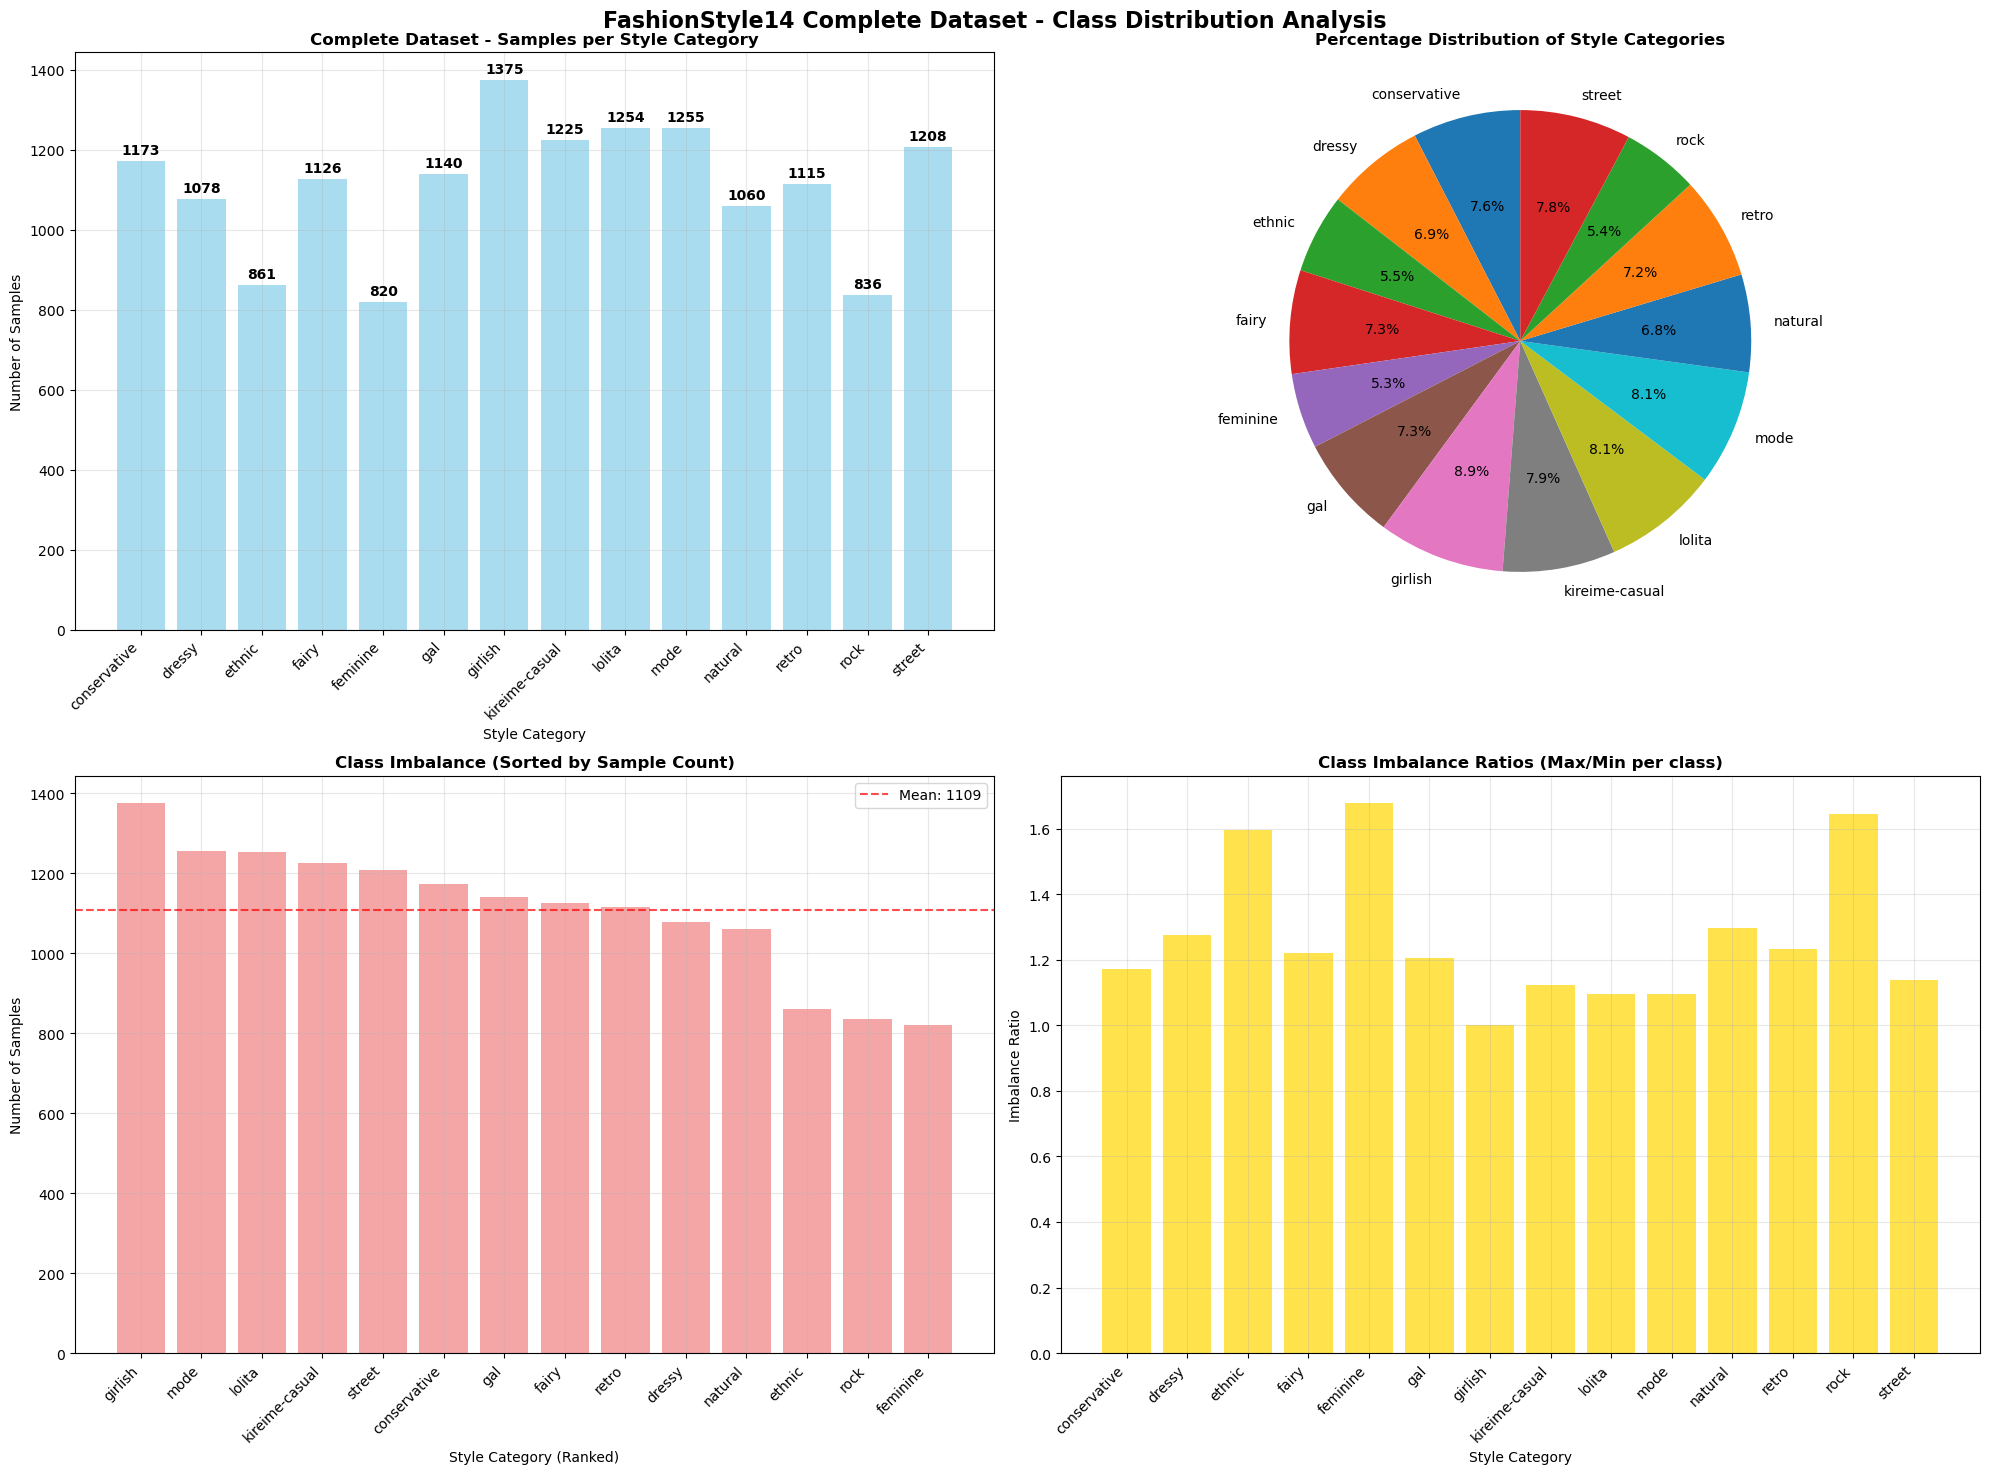

In [20]:
# Visualize class distribution
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('FashionStyle14 Complete Dataset - Class Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Bar chart of class distribution
axes[0, 0].bar(range(len(style_distribution)), style_distribution.values, color='skyblue', alpha=0.7)
axes[0, 0].set_title('Complete Dataset - Samples per Style Category', fontweight='bold')
axes[0, 0].set_xlabel('Style Category')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_xticks(range(len(style_distribution)))
axes[0, 0].set_xticklabels(style_distribution.index, rotation=45, ha='right')
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(style_distribution.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Pie chart
axes[0, 1].pie(style_distribution.values, labels=style_distribution.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Percentage Distribution of Style Categories', fontweight='bold')

# 3. Sorted distribution (imbalance visualization)
sorted_dist = style_distribution.sort_values(ascending=False)
axes[1, 0].bar(range(len(sorted_dist)), sorted_dist.values, color='lightcoral', alpha=0.7)
axes[1, 0].set_title('Class Imbalance (Sorted by Sample Count)', fontweight='bold')
axes[1, 0].set_xlabel('Style Category (Ranked)')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_xticks(range(len(sorted_dist)))
axes[1, 0].set_xticklabels(sorted_dist.index, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# Add horizontal line for mean
mean_samples = style_distribution.mean()
axes[1, 0].axhline(y=mean_samples, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_samples:.0f}')
axes[1, 0].legend()

# 4. Class imbalance ratio visualization
imbalance_ratios = style_distribution.max() / style_distribution
axes[1, 1].bar(range(len(imbalance_ratios)), imbalance_ratios.values, color='gold', alpha=0.7)
axes[1, 1].set_title('Class Imbalance Ratios (Max/Min per class)', fontweight='bold')
axes[1, 1].set_xlabel('Style Category')
axes[1, 1].set_ylabel('Imbalance Ratio')
axes[1, 1].set_xticks(range(len(imbalance_ratios)))
axes[1, 1].set_xticklabels(imbalance_ratios.index, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Image Properties Analysis

In [21]:
def analyze_image_properties(df, sample_size=1000):
    """
    Analyze image properties for a sample of the dataset
    """
    print(f"Analyzing image properties (sampling {min(sample_size, len(df))} images)...")
    
    # Sample images for analysis
    sample_df = df.sample(n=min(sample_size, len(df)), random_state=42)
    
    image_props = []
    file_sizes = []
    file_formats = []
    
    for idx, row in sample_df.iterrows():
        try:
            image_path = row['image_path']
            
            if os.path.exists(image_path):
                # Get file size
                file_size = os.path.getsize(image_path)
                file_sizes.append(file_size)
                
                # Get file format
                file_format = image_path.split('.')[-1].lower()
                file_formats.append(file_format)
                
                # Get image dimensions
                with Image.open(image_path) as img:
                    width, height = img.size
                    image_props.append({
                        'width': width,
                        'height': height,
                        'aspect_ratio': width / height,
                        'total_pixels': width * height,
                        'file_size': file_size,
                        'format': file_format,
                        'style': row['style']
                    })
            else:
                print(f"Warning: File not found: {image_path}")
                
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
    
    return pd.DataFrame(image_props), file_sizes, file_formats

# Analyze image properties
image_props_df, file_sizes, file_formats = analyze_image_properties(complete_dataset, 1000)

print(f"Successfully analyzed {len(image_props_df)} images")

# Display image properties summary
print("Image Properties Summary:")
print(f"Total images analyzed: {len(image_props_df)}")
print(f"\nDimension Statistics:")
print(f"Width - Mean: {image_props_df['width'].mean():.1f}, Std: {image_props_df['width'].std():.1f}")
print(f"Height - Mean: {image_props_df['height'].mean():.1f}, Std: {image_props_df['height'].std():.1f}")
print(f"Aspect Ratio - Mean: {image_props_df['aspect_ratio'].mean():.2f}, Std: {image_props_df['aspect_ratio'].std():.2f}")
print(f"Total Pixels - Mean: {image_props_df['total_pixels'].mean():.0f}, Std: {image_props_df['total_pixels'].std():.0f}")

print(f"\nFile Size Statistics:")
print(f"Mean: {np.mean(file_sizes) / 1024:.1f} KB, Std: {np.std(file_sizes) / 1024:.1f} KB")
print(f"Min: {np.min(file_sizes) / 1024:.1f} KB, Max: {np.max(file_sizes) / 1024:.1f} KB")

print(f"\nFile Format Distribution:")
format_counts = Counter(file_formats)
for format_type, count in format_counts.most_common():
    print(f"{format_type}: {count} ({count/len(file_formats)*100:.1f}%)")

Analyzing image properties (sampling 1000 images)...
Error processing FashionStyle14_v1/dataset/gal/._221403558.jpg: cannot identify image file 'FashionStyle14_v1/dataset/gal/._221403558.jpg'
Error processing FashionStyle14_v1/dataset/dressy/._o065011251017824_650.jpg: cannot identify image file 'FashionStyle14_v1/dataset/dressy/._o065011251017824_650.jpg'
Error processing FashionStyle14_v1/dataset/gal/._15276682_615877291930415_756876814986510336_n.jpg: cannot identify image file 'FashionStyle14_v1/dataset/gal/._15276682_615877291930415_756876814986510336_n.jpg'
Error processing FashionStyle14_v1/dataset/conservative/._20cfce153c6dcbd30dc35695758066ae3-e1361101648728.jpg: cannot identify image file 'FashionStyle14_v1/dataset/conservative/._20cfce153c6dcbd30dc35695758066ae3-e1361101648728.jpg'
Error processing FashionStyle14_v1/dataset/lolita/._5b2d230ca470073dfd9b8a03c9b61c28.jpg: cannot identify image file 'FashionStyle14_v1/dataset/lolita/._5b2d230ca470073dfd9b8a03c9b61c28.jpg'
Erro